## 1. Environment Setup

In [1]:
from google.colab import drive, userdata
from pathlib import Path
from zipfile import ZipFile
import pandas as pd
import sys

drive.mount('/content/drive')

DATA_ROOT = Path("/content/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset")
PED1_PATH = DATA_ROOT / "UCSDped1"
PED2_PATH = DATA_ROOT / "UCSDped2"
ZIP_PATH = Path("/content/drive/MyDrive/SurveillanceAnomalyDetection/UCSD_Anomaly_Dataset.zip")
EXTRACT_PATH = Path("/content/UCSD_Anomaly_Dataset")

if not (PED1_PATH.exists() and PED2_PATH.exists()):
  with ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_PATH)

GH_TOKEN = userdata.get("GH_PAT")
REPO_DIR = Path("/content/drive/MyDrive/SurveillanceAnomalyDetection/repo")
REPO_URL = f"https://{GH_TOKEN}@github.com/Rishabh-G-Shetye/SurveillanceAnomalyDetection.git"
if not REPO_DIR.exists():
  !git clone {REPO_URL} "{REPO_DIR}"
%cd "{REPO_DIR}"

sys.path.insert(0, str(REPO_DIR / "src"))

df = pd.read_csv(REPO_DIR / "data" / "metadata.csv")
from data.ucsd_dataset import PreprocessConfig, UCSDClipDataset

ped1_config = PreprocessConfig(target_size=(128, 128), window_length=8, stride=4)
train_ds = UCSDClipDataset(df, DATA_ROOT, "Ped1", "Train", ped1_config)
test_ds = UCSDClipDataset(df, DATA_ROOT, "Ped1", "Test", ped1_config)
print("Train clips:", len(train_ds), "| Test clips:", len(test_ds))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/SurveillanceAnomalyDetection/repo
Train clips: 1666 | Test clips: 1762


## 2. Module Directories  

In [2]:
import os
for sub in ["models", "training", "evaluation"]:
  os.makedirs(REPO_DIR / "src" / sub, exist_ok=True)
  (REPO_DIR / "src" / sub / "__init__.py").touch()

## 3. Base Model Interface

In [3]:
%%writefile "{REPO_DIR}/src/models/base.py"
"""
Common interface for manageing all the anomaly detection models in the project.

Every model implements:
- forward(clip): (B, T, 1, H, W) -> model-specific output
- compute_loss(clip): self-supervised loss, no labels needed
- anomaly_score(clip): (B,) float score, HIGHER = more anomalous

Purpose is such that a single trainer and a sinle evaluation module works with any model following this contract, so new architectures plug in without touching the training and the evaluation code.
"""

from abc import ABC, abstractmethod
import torch
import torch.nn as nn

class BaseAnomalyModel(nn.Module, ABC):
  """Abstract base class all the anomaly detection models must implement"""

  @abstractmethod
  def forward(self, clip: torch.Tensor) -> torch.Tensor:
    raise NotImplementedError

  @abstractmethod
  def compute_loss(self, clip: torch.Tensor) -> torch.Tensor:
    raise NotImplementedError

  @abstractmethod
  def anomaly_score(self, clip: torch.Tensor) -> torch.Tensor:
    raise NotImplementedError


Overwriting /content/drive/MyDrive/SurveillanceAnomalyDetection/repo/src/models/base.py


## 4. Model 1 - Baseline ConvAE

In [4]:
%%writefile "{REPO_DIR}/src/models/conv_ae.py"
import torch
import torch.nn as nn
import torch.nn.functional as F

from .base import BaseAnomalyModel

class ConvAE(BaseAnomalyModel):
    def __init__(self, in_channels: int = 1, latent_channels: int = 64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, latent_channels, 4, stride=2, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, in_channels, 4, stride=2, padding=1), nn.Tanh(),
        )

    def forward(self, clip: torch.Tensor) -> torch.Tensor:
        B, T, C, H, W = clip.shape
        x = clip.view(B * T, C, H, W)
        recon = self.decoder(self.encoder(x))
        return recon.view(B, T, C, H, W)

    def compute_loss(self, clip: torch.Tensor) -> torch.Tensor:
        recon = self.forward(clip)
        return F.mse_loss(recon, clip)

    @torch.no_grad()
    def anomaly_score(self, clip: torch.Tensor) -> torch.Tensor:
        recon = self.forward(clip)
        per_frame_error = ((recon - clip) ** 2).mean(dim=(2, 3, 4))  # (B, T)
        return per_frame_error.mean(dim=1)  # (B,)

Overwriting /content/drive/MyDrive/SurveillanceAnomalyDetection/repo/src/models/conv_ae.py


In [5]:
from models.conv_ae import ConvAE
model = ConvAE()

## 5. Shared Training Loop

In [6]:
%%writefile "{REPO_DIR}/src/training/trainer.py"
"""
Generic training loop shared by every Base Anomaly Model implementation.

"""

from typing import Optional
import torch
from torch.utils.data import DataLoader

def train_model(
    model: torch.nn.Module,
    train_loader: DataLoader,
    num_epochs: int = 10,
    lr: float = 1e-3,
    device: Optional[str] = None,
) -> list:
    """Trains model in place. Returns per-epoch mean loss."""
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for batch in train_loader:
            clip = batch["clip"].to(device)
            optimizer.zero_grad()
            loss = model.compute_loss(clip)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * clip.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        history.append(epoch_loss)
        print(f"Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.6f}")
    return history

Overwriting /content/drive/MyDrive/SurveillanceAnomalyDetection/repo/src/training/trainer.py


## 6. Shared Evaluation Metrics

In [7]:
%%writefile "{REPO_DIR}/src/evaluation/metrics.py"
"""
Evaluation metrics for anomaly detection: AUC-ROC, EER, precision/recall/F1
"""

import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_fscore_support


def compute_eer(labels: np.ndarray, scores: np.ndarray) -> float:
    """Equal Error Rate: point where false positive rate == false negative rate."""
    fpr, tpr, _ = roc_curve(labels, scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[eer_idx] + fnr[eer_idx]) / 2)


def evaluate_scores(labels: np.ndarray, scores: np.ndarray, threshold: float = None) -> dict:
    """labels: 0/1 ground truth (1=anomalous). scores: higher = more anomalous."""
    auc = roc_auc_score(labels, scores)
    eer = compute_eer(labels, scores)

    if threshold is None:
        threshold = float(np.median(scores))
    preds = (scores >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )

    return {
        "auc_roc": auc, "eer": eer,
        "precision": precision, "recall": recall, "f1": f1,
        "threshold_used": threshold,
    }

Overwriting /content/drive/MyDrive/SurveillanceAnomalyDetection/repo/src/evaluation/metrics.py


## 7. Train ConvAE and Evaluate

In [8]:
from torch.utils.data import DataLoader
from models.conv_ae import ConvAE
from training.trainer import train_model

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

model = ConvAE()
history = train_model(model, train_loader, num_epochs=10, lr=1e-3)

Epoch 1/10 - loss: 0.068243
Epoch 2/10 - loss: 0.016712
Epoch 3/10 - loss: 0.010492
Epoch 4/10 - loss: 0.007900
Epoch 5/10 - loss: 0.006385
Epoch 6/10 - loss: 0.005528
Epoch 7/10 - loss: 0.005022
Epoch 8/10 - loss: 0.004488
Epoch 9/10 - loss: 0.004027
Epoch 10/10 - loss: 0.003718


In [9]:
import torch
import numpy as np
from evaluation.metrics import evaluate_scores

device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval()

all_scores, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        clip = batch["clip"].to(device)
        scores = model.anomaly_score(clip)
        all_scores.append(scores.cpu().numpy())
        all_labels.append(batch["clip_label"].numpy())

all_scores = np.concatenate(all_scores)
all_labels = np.concatenate(all_labels)

results = evaluate_scores(all_labels, all_scores)
print("ConvAE (baseline) results:", results)

ConvAE (baseline) results: {'auc_roc': np.float64(0.6349670638034767), 'eer': 0.438918326447755, 'precision': 0.21566401816118047, 'recall': 0.5919003115264797, 'f1': 0.3161397670549085, 'threshold_used': 0.004117639269679785}


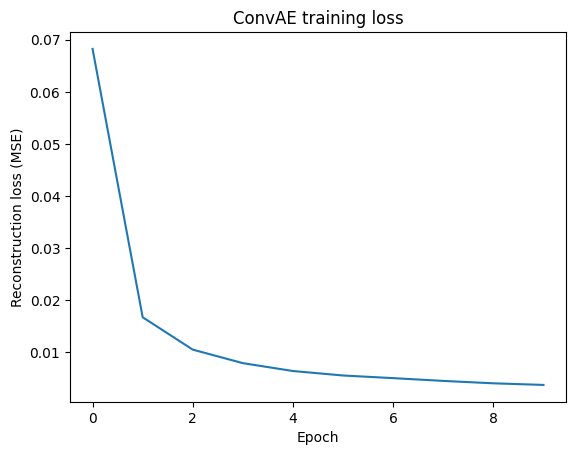

In [10]:
import matplotlib.pyplot as plt

plt.plot(history)
plt.xlabel("Epoch"); plt.ylabel("Reconstruction loss (MSE)")
plt.title("ConvAE training loss")
plt.show()

In [12]:
%cd "{REPO_DIR}"
!git add notebooks/04_ucsd_model_ecperiments.ipynb
!git commit -m "feat: Implement and evaluate ConvAE baseline model"
!git push

/content/drive/MyDrive/SurveillanceAnomalyDetection/repo
fatal: pathspec 'notebooks/04_ucsd_model_ecperiments.ipynb' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/01_ucsd_dataset_setup.ipynb
	modified:   notebooks/02_ucsd_dataset_exploration.ipynb
	modified:   notebooks/03_ucsd_preprocessing_pipeline.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/04_ucsd_model_experiments.ipynb
	src/

no changes added to commit (use "git add" and/or "git commit -a")
Everything up-to-date
